# Credit Risk Prediction - End-to-End ML Pipeline
## Analysis of SBA Loan Data (1991-2019)

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.impute import SimpleImputer
import pickle
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Load Data from Different Time Periods

In [17]:
df1 = pd.read_csv('foia-7afy1991-fy1999-asof-221231.csv', encoding='latin1', low_memory=False)
df2 = pd.read_csv('foia-7afy2000-fy2009-asof-221231.csv', encoding='latin1', low_memory=False)
df3 = pd.read_csv('foia-7afy2010-fy2019-asof-221231.csv', encoding='latin1', low_memory=False)
print(f'Period 1 (1991-1999): {df1.shape}')
print(f'Period 2 (2000-2009): {df2.shape}')
print(f'Period 3 (2010-2019): {df3.shape}')

Period 1 (1991-1999): (337043, 39)
Period 2 (2000-2009): (690347, 39)
Period 3 (2010-2019): (545751, 39)


## 2. Compare Data Structure Across Time Periods

In [18]:
print('Column counts:', df1.shape[1], df2.shape[1], df3.shape[1])
print('Columns match:', set(df1.columns) == set(df2.columns) == set(df3.columns))
print('\nCommon columns:', len(set(df1.columns) & set(df2.columns) & set(df3.columns)))

Column counts: 39 39 39
Columns match: True

Common columns: 39


In [19]:
print('Missing Values by Period:\n')
for i, df in enumerate([df1, df2, df3], 1):
    print(f'Period {i}: Top missing columns')
    print(df.isnull().sum().sort_values(ascending=False).head(10))
    print()

Missing Values by Period:

Period 1: Top missing columns
InitialInterestRate      337043
BusinessAge              337043
BankNCUANumber           336170
FranchiseName            315476
FranchiseCode            315457
ChargeOffDate            301719
NaicsDescription         184091
NaicsCode                183986
PaidInFullDate            81192
FirstDisbursementDate     43381
dtype: int64

Period 2: Top missing columns
BusinessAge              690347
BankNCUANumber           679570
InitialInterestRate      653713
FranchiseName            650710
FranchiseCode            650698
ChargeOffDate            543811
PaidInFullDate           236693
FirstDisbursementDate     82740
BankFDICNumber            71563
NaicsDescription          19796
dtype: int64

Period 3: Top missing columns
BankNCUANumber           528963
ChargeOffDate            517836
FranchiseName            498237
FranchiseCode            498136
BusinessAge              434078
PaidInFullDate           226522
FirstDisbursementDate  

In [20]:
for i, df in enumerate([df1, df2, df3], 1):
    period = ['1991-1999', '2000-2009', '2010-2019'][i-1]
    print(f'\n=== Period {period} ===')
    print(f'Total Loans: {len(df):,}')
    if 'LoanStatus' in df.columns:
        print(f'Loan Status:\n{df.LoanStatus.value_counts()}')
    if 'GrossApproval' in df.columns:
        print(f'Avg Approval: ${df.GrossApproval.mean():,.2f}')


=== Period 1991-1999 ===
Total Loans: 337,043
Loan Status:
LoanStatus
PIF       255851
CANCLD     43667
CHGOFF     35362
EXEMPT      2163
Name: count, dtype: int64
Avg Approval: $206,560.90

=== Period 2000-2009 ===
Total Loans: 690,347
Loan Status:
LoanStatus
PIF       453654
CHGOFF    146540
CANCLD     82278
EXEMPT      7875
Name: count, dtype: int64
Avg Approval: $178,707.92

=== Period 2010-2019 ===
Total Loans: 545,751
Loan Status:
LoanStatus
PIF       319229
EXEMPT    131702
CANCLD     65743
CHGOFF     27916
COMMIT      1161
Name: count, dtype: int64
Avg Approval: $377,395.86


## 3. Merge and Prepare Combined Dataset

In [21]:
df1['TimePeriod'] = '1991-1999'
df2['TimePeriod'] = '2000-2009'
df3['TimePeriod'] = '2010-2019'
df = pd.concat([df1, df2, df3], ignore_index=True)
print(f'Combined shape: {df.shape}')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

Combined shape: (1573141, 40)
Memory usage: 2355.12 MB


## 4. Data Cleaning and Preprocessing

In [22]:
print('Initial shape:', df.shape)
print('\nTarget variable (LoanStatus):')
print(df['LoanStatus'].value_counts())
print(f'\nMissing values:\n{df.isnull().sum().sort_values(ascending=False).head(15)}')

Initial shape: (1573141, 40)

Target variable (LoanStatus):
LoanStatus
PIF       1028734
CHGOFF     209818
CANCLD     191688
EXEMPT     141740
COMMIT       1161
Name: count, dtype: int64

Missing values:
BankNCUANumber           1544703
FranchiseName            1464423
FranchiseCode            1464291
BusinessAge              1461468
ChargeOffDate            1363366
InitialInterestRate       990756
PaidInFullDate            544407
NaicsDescription          204481
NaicsCode                 203728
FirstDisbursementDate     191135
BankFDICNumber            148864
CongressionalDistrict       3407
BankState                   2082
BankZip                     2048
BankStreet                  2037
dtype: int64


In [23]:
# Create target variable WITHOUT DATA LEAKAGE
# Use GrossChargeOffAmount instead of LoanStatus
df["IsDefault"] = (df["GrossChargeOffAmount"] > 0).astype(int)

print("Target Distribution:")
print(df["IsDefault"].value_counts())
print(f"Default Rate: {df.IsDefault.mean()*100:.2f}%")
print("✓ No data leakage - using charge-off amount, not status")

Target Distribution:
IsDefault
0    1363491
1     209650
Name: count, dtype: int64
Default Rate: 13.33%
✓ No data leakage - using charge-off amount, not status


In [24]:
# Add temporal features (CRITICAL for credit risk)
df["ApprovalDate"] = pd.to_datetime(df["ApprovalDate"], errors="coerce")
df["FirstDisbursementDate"] = pd.to_datetime(df["FirstDisbursementDate"], errors="coerce")

df["ApprovalYear"] = df["ApprovalDate"].dt.year
df["ApprovalMonth"] = df["ApprovalDate"].dt.month
df["ApprovalQuarter"] = df["ApprovalDate"].dt.quarter
df["DisbursementYear"] = df["FirstDisbursementDate"].dt.year
df["DisbursementMonth"] = df["FirstDisbursementDate"].dt.month

# Days between approval and disbursement (processing time indicator)
df["DaysToDisbursement"] = (df["FirstDisbursementDate"] - df["ApprovalDate"]).dt.days

# CRITICAL FIX: Explicit NaN handling for temporal features
# Note: NaN values will be imputed later in the pipeline (after split)
# This is intentional to avoid data leakage

print("Temporal features created:")
print(f"  ApprovalYear: {df.ApprovalYear.min():.0f} - {df.ApprovalYear.max():.0f}")
print(f"  DaysToDisbursement: median = {df.DaysToDisbursement.median():.0f} days")
print(f"  Missing DaysToDisbursement: {df.DaysToDisbursement.isnull().sum():,} ({df.DaysToDisbursement.isnull().sum()/len(df)*100:.1f}%)")
print("  Note: NaN values will be imputed after train-test split to prevent leakage")

Temporal features created:
  ApprovalYear: 1990 - 2019
  DaysToDisbursement: median = 41 days
  Missing DaysToDisbursement: 191,135 (12.1%)
  Note: NaN values will be imputed after train-test split to prevent leakage


## 4. Feature Selection and Train-Test Split (BEFORE Preprocessing)

In [25]:
# Select RAW features (no preprocessing yet)
feature_cols = [
    "GrossApproval", "SBAGuaranteedApproval", "TermInMonths", "JobsSupported",
    "InitialInterestRate", "NaicsCode", "Program", "DeliveryMethod",
    "BorrState", "ProjectState", "BusinessType", "TimePeriod",
    "ApprovalYear", "ApprovalMonth", "ApprovalQuarter",
    "DisbursementYear", "DisbursementMonth", "DaysToDisbursement"
]

# Filter to existing columns
feature_cols = [f for f in feature_cols if f in df.columns]
print(f"Selected {len(feature_cols)} features")

# Create feature matrix and target
X = df[feature_cols].copy()
y = df["IsDefault"].copy()

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Default rate: {y.mean()*100:.2f}%")

Selected 18 features

X shape: (1573141, 18)
y shape: (1573141,)
Default rate: 13.33%


In [26]:
# CRITICAL: Split BEFORE any preprocessing
print("Splitting data BEFORE preprocessing to prevent leakage...")

# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: 75% train, 25% val (of temp)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

# CRITICAL FIX: Make explicit copies to avoid SettingWithCopyWarning
X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()
print("✓ Created independent copies of train/val/test sets")

print(f"Train: {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Val:   {X_val.shape[0]:,} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test:  {X_test.shape[0]:,} ({X_test.shape[0]/len(X)*100:.1f}%)")

# Calculate class weight
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"Class imbalance ratio: {scale_pos_weight:.2f}:1")

Splitting data BEFORE preprocessing to prevent leakage...
✓ Created independent copies of train/val/test sets
Train: 943,884 (60.0%)
Val:   314,628 (20.0%)
Test:  314,629 (20.0%)
Class imbalance ratio: 6.50:1


## 5. Preprocessing (FIT on Train, TRANSFORM on Val/Test)

In [27]:
# Identify feature types
numeric_cols = [
    "GrossApproval", "SBAGuaranteedApproval", "TermInMonths", "JobsSupported",
    "InitialInterestRate", "NaicsCode",
    "ApprovalYear", "ApprovalMonth", "ApprovalQuarter",
    "DisbursementYear", "DisbursementMonth", "DaysToDisbursement"
]
categorical_cols = ["Program", "DeliveryMethod", "BorrState", "ProjectState", "BusinessType", "TimePeriod"]

numeric_features = [c for c in numeric_cols if c in X_train.columns]
categorical_features = [c for c in categorical_cols if c in X_train.columns]

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

Numeric features: 12
Categorical features: 6


In [28]:
# Step 1: Impute missing values (FIT on train only)
print("Step 1: Imputation (fit on train only)...")

# Numeric imputation
imputer_num = SimpleImputer(strategy="median")
X_train[numeric_features] = imputer_num.fit_transform(X_train[numeric_features])
X_val[numeric_features] = imputer_num.transform(X_val[numeric_features])
X_test[numeric_features] = imputer_num.transform(X_test[numeric_features])

# Categorical imputation
imputer_cat = SimpleImputer(strategy="most_frequent")
X_train[categorical_features] = imputer_cat.fit_transform(X_train[categorical_features])
X_val[categorical_features] = imputer_cat.transform(X_val[categorical_features])
X_test[categorical_features] = imputer_cat.transform(X_test[categorical_features])

print(f"Train NaN: {X_train.isnull().sum().sum()}")
print(f"Val NaN: {X_val.isnull().sum().sum()}")
print(f"Test NaN: {X_test.isnull().sum().sum()}")

Step 1: Imputation (fit on train only)...
Train NaN: 0
Val NaN: 0
Test NaN: 0


In [29]:
# Step 2: Encode categorical features (FIT on train only)
print("Step 2: Encoding (fit on train only)...")

# Separate high and low cardinality
high_cardinality = ["BorrState", "ProjectState"]
low_cardinality = [c for c in categorical_features if c not in high_cardinality]

print(f"High cardinality: {high_cardinality}")
print(f"Low cardinality: {low_cardinality}")

# Label encode low cardinality with SAFE handling of unseen categories
label_encoders = {}
for col in low_cardinality:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    
    # CRITICAL FIX: Use default parameters to capture VALUES, not references
    # This prevents closure bug where all functions reference the last iteration's variables
    known_classes_copy = set(le.classes_).copy()
    unknown_value = len(le.classes_)  # Assign new index for unknown
    
    def safe_transform(val, known=known_classes_copy, unk=unknown_value, encoder=le):
        if val in known:
            return encoder.transform([val])[0]
        return unk
    
    X_val[col] = X_val[col].astype(str).apply(safe_transform)
    X_test[col] = X_test[col].astype(str).apply(safe_transform)
    label_encoders[col] = le

print(f"✓ Label encoding complete with unseen category handling (closure bug fixed)")

# Target encode high cardinality (FIT on train only)
from sklearn.preprocessing import TargetEncoder
target_encoder = TargetEncoder()
X_train[high_cardinality] = target_encoder.fit_transform(X_train[high_cardinality], y_train)
X_val[high_cardinality] = target_encoder.transform(X_val[high_cardinality])
X_test[high_cardinality] = target_encoder.transform(X_test[high_cardinality])

print("✓ Target encoding complete")

Step 2: Encoding (fit on train only)...
High cardinality: ['BorrState', 'ProjectState']
Low cardinality: ['Program', 'DeliveryMethod', 'BusinessType', 'TimePeriod']
✓ Label encoding complete with unseen category handling (closure bug fixed)
✓ Target encoding complete


In [31]:
# Step 3: Feature engineering (using TRAIN statistics only)
print("Step 3: Feature engineering (using train stats only)...")

# Calculate medians from TRAIN only for filling NaN in engineered features
train_guarantee_median = None  # Will calculate after creation
train_loanperjob_median = None
train_interestterm_median = None

for X_set in [X_train, X_val, X_test]:
    # 1. Guarantee Ratio
    X_set["GuaranteeRatio"] = np.where(
        X_set["GrossApproval"] > 0,
        X_set["SBAGuaranteedApproval"] / X_set["GrossApproval"],
        0
    )
    
    # 2. Jobs indicator
    X_set["HasJobs"] = (X_set["JobsSupported"] > 0).astype(int)
    
    # 3. Loan per job
    X_set["LoanPerJob"] = np.where(
        X_set["JobsSupported"] > 0,
        X_set["GrossApproval"] / X_set["JobsSupported"],
        X_set["GrossApproval"]
    )
    
    # 4. Interest-Term product
    X_set["InterestTermProduct"] = X_set["InitialInterestRate"] * X_set["TermInMonths"]
    
    # 5. Loan size bins (handle NaN before converting to int)
    X_set["LoanSize"] = pd.cut(X_set["GrossApproval"], 
                                bins=[0, 50000, 150000, 350000, np.inf],
                                labels=[0, 1, 2, 3])
    # Converts to int, NaN becomes -1
    X_set["LoanSize"] = X_set["LoanSize"].cat.codes

# Calculate medians from TRAIN set only
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
train_guarantee_median = X_train["GuaranteeRatio"].median()
train_loanperjob_median = X_train["LoanPerJob"].median()
train_interestterm_median = X_train["InterestTermProduct"].median()

# Fill NaN with TRAIN medians for all sets
for X_set in [X_train, X_val, X_test]:
    X_set.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_set["GuaranteeRatio"].fillna(train_guarantee_median, inplace=True)
    X_set["LoanPerJob"].fillna(train_loanperjob_median, inplace=True)
    X_set["InterestTermProduct"].fillna(train_interestterm_median, inplace=True)
    # Handle LoanSize NaN (represented as -1 from cat.codes)
    X_set["LoanSize"] = X_set["LoanSize"].replace(-1, 0)  # Default to smallest bin

print(f"✓ Feature engineering complete")
print(f"  Train shape: {X_train.shape}")
print(f"  Val shape: {X_val.shape}")
print(f"  Test shape: {X_test.shape}")
print(f"  Train NaN: {X_train.isnull().sum().sum()}")

Step 3: Feature engineering (using train stats only)...
✓ Feature engineering complete
  Train shape: (943884, 23)
  Val shape: (314628, 23)
  Test shape: (314629, 23)
  Train NaN: 0


In [32]:
# Step 4: Scale features (FIT on train only)
print("\nStep 4: Scaling (fit on train only)...")

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=X_val.columns,
    index=X_val.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print(f"Scaled train: {X_train_scaled.shape}")
print(f"Scaled val: {X_val_scaled.shape}")
print(f"Scaled test: {X_test_scaled.shape}")
print(f"\nNaN check: {X_train_scaled.isnull().sum().sum()}")
print(f"Inf check: {np.isinf(X_train_scaled).sum().sum()}")
print("\n✓ Preprocessing complete - NO DATA LEAKAGE")


Step 4: Scaling (fit on train only)...
Scaled train: (943884, 23)
Scaled val: (314628, 23)
Scaled test: (314629, 23)

NaN check: 0
Inf check: 0

✓ Preprocessing complete - NO DATA LEAKAGE


In [33]:
# CRITICAL: Final data quality validation before training
print("="*70)
print("FINAL DATA QUALITY VALIDATION")
print("="*70)

# Check for NaN
print(f"1. NaN Check:")
print(f"   Train NaN: {X_train.isnull().sum().sum()}")
print(f"   Val NaN: {X_val.isnull().sum().sum()}")
print(f"   Test NaN: {X_test.isnull().sum().sum()}")
print(f"   Train scaled NaN: {X_train_scaled.isnull().sum().sum()}")

# Check for Inf
print(f"2. Inf Check:")
print(f"   Train Inf: {np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum()}")
print(f"   Val Inf: {np.isinf(X_val.select_dtypes(include=[np.number])).sum().sum()}")
print(f"   Test Inf: {np.isinf(X_test.select_dtypes(include=[np.number])).sum().sum()}")

# Check shapes
print(f"3. Shape Check:")
print(f"   X_train: {X_train.shape}")
print(f"   X_val: {X_val.shape}")
print(f"   X_test: {X_test.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_val: {y_val.shape}")
print(f"   y_test: {y_test.shape}")

# Check feature consistency
print(f"4. Feature Consistency:")
print(f"   Train features: {X_train.shape[1]}")
print(f"   Val features: {X_val.shape[1]}")
print(f"   Test features: {X_test.shape[1]}")
print(f"   All match: {X_train.shape[1] == X_val.shape[1] == X_test.shape[1]}")

# Check target distribution
print(f"5. Target Distribution:")
print(f"   Train default rate: {y_train.mean()*100:.2f}%")
print(f"   Val default rate: {y_val.mean()*100:.2f}%")
print(f"   Test default rate: {y_test.mean()*100:.2f}%")

# Final validation
all_valid = (
    X_train.isnull().sum().sum() == 0 and
    X_val.isnull().sum().sum() == 0 and
    X_test.isnull().sum().sum() == 0 and
    np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum() == 0 and
    X_train.shape[1] == X_val.shape[1] == X_test.shape[1]
)

if all_valid:
    print("" + "="*70)
    print("✓ ALL VALIDATION CHECKS PASSED - READY FOR TRAINING")
    print("="*70)
else:
    print("" + "="*70)
    print("❌ VALIDATION FAILED - CHECK DATA QUALITY")
    print("="*70)
    raise ValueError("Data quality validation failed")

FINAL DATA QUALITY VALIDATION
1. NaN Check:
   Train NaN: 0
   Val NaN: 0
   Test NaN: 0
   Train scaled NaN: 0
2. Inf Check:
   Train Inf: 0
   Val Inf: 0
   Test Inf: 0
3. Shape Check:
   X_train: (943884, 23)
   X_val: (314628, 23)
   X_test: (314629, 23)
   y_train: (943884,)
   y_val: (314628,)
   y_test: (314629,)
4. Feature Consistency:
   Train features: 23
   Val features: 23
   Test features: 23
   All match: True
5. Target Distribution:
   Train default rate: 13.33%
   Val default rate: 13.33%
   Test default rate: 13.33%
✓ ALL VALIDATION CHECKS PASSED - READY FOR TRAINING


## 6. Model Training and Evaluation

In [34]:
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr.fit(X_train_scaled, y_train)

# Evaluate on validation and test
lr_val_prob = lr.predict_proba(X_val_scaled)[:, 1]
lr_test_prob = lr.predict_proba(X_test_scaled)[:, 1]
lr_val_pred = lr.predict(X_val_scaled)
lr_test_pred = lr.predict(X_test_scaled)

print(f"Val ROC-AUC: {roc_auc_score(y_val, lr_val_prob):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, lr_test_prob):.4f}")
print("Test Set Classification Report:")
print(classification_report(y_test, lr_test_pred))

Training Logistic Regression...
Val ROC-AUC: 0.8121
Test ROC-AUC: 0.8122
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.70      0.81    272699
           1       0.29      0.80      0.42     41930

    accuracy                           0.71    314629
   macro avg       0.62      0.75      0.61    314629
weighted avg       0.87      0.71      0.75    314629



In [36]:
print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100, max_depth=10, class_weight="balanced",
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

rf_val_prob = rf.predict_proba(X_val)[:, 1]
rf_test_prob = rf.predict_proba(X_test)[:, 1]
rf_val_pred = rf.predict(X_val)
rf_test_pred = rf.predict(X_test)

print(f"Val ROC-AUC: {roc_auc_score(y_val, rf_val_prob):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, rf_test_prob):.4f}")
print("Test Set Classification Report:")
print(classification_report(y_test, rf_test_pred))

Training Random Forest...
Val ROC-AUC: 0.9509
Test ROC-AUC: 0.9511
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.88      0.93    272699
           1       0.53      0.89      0.67     41930

    accuracy                           0.88    314629
   macro avg       0.76      0.89      0.80    314629
weighted avg       0.92      0.88      0.89    314629



In [37]:
print("Training Gradient Boosting...")
sample_weight = np.where(y_train == 1, scale_pos_weight, 1.0)
gb = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
gb.fit(X_train, y_train, sample_weight=sample_weight)

gb_val_prob = gb.predict_proba(X_val)[:, 1]
gb_test_prob = gb.predict_proba(X_test)[:, 1]
gb_val_pred = gb.predict(X_val)
gb_test_pred = gb.predict(X_test)

print(f"Val ROC-AUC: {roc_auc_score(y_val, gb_val_prob):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, gb_test_prob):.4f}")
print("Test Set Classification Report:")
print(classification_report(y_test, gb_test_pred))

Training Gradient Boosting...
Val ROC-AUC: 0.9680
Test ROC-AUC: 0.9678
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.94    272699
           1       0.58      0.94      0.71     41930

    accuracy                           0.90    314629
   macro avg       0.78      0.92      0.83    314629
weighted avg       0.93      0.90      0.91    314629



In [38]:
print("Training XGBoost...")
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, random_state=42,
    n_jobs=-1, eval_metric="logloss"
)
xgb.fit(X_train, y_train)

xgb_val_prob = xgb.predict_proba(X_val)[:, 1]
xgb_test_prob = xgb.predict_proba(X_test)[:, 1]
xgb_val_pred = xgb.predict(X_val)
xgb_test_pred = xgb.predict(X_test)

print(f"Val ROC-AUC: {roc_auc_score(y_val, xgb_val_prob):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, xgb_test_prob):.4f}")
print("Test Set Classification Report:")
print(classification_report(y_test, xgb_test_pred))

Training XGBoost...
Val ROC-AUC: 0.9653
Test ROC-AUC: 0.9652
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.88      0.93    272699
           1       0.56      0.94      0.70     41930

    accuracy                           0.89    314629
   macro avg       0.77      0.91      0.82    314629
weighted avg       0.93      0.89      0.90    314629



## 7. Model Comparison and Selection

In [39]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting", "XGBoost"],
    "Val_AUC": [
        roc_auc_score(y_val, lr_val_prob),
        roc_auc_score(y_val, rf_val_prob),
        roc_auc_score(y_val, gb_val_prob),
        roc_auc_score(y_val, xgb_val_prob)
    ],
    "Test_AUC": [
        roc_auc_score(y_test, lr_test_prob),
        roc_auc_score(y_test, rf_test_prob),
        roc_auc_score(y_test, gb_test_prob),
        roc_auc_score(y_test, xgb_test_prob)
    ]
})

print("Model Performance Comparison:")
print(results.sort_values("Test_AUC", ascending=False))

# Select best model based on validation AUC
best_idx = results["Val_AUC"].idxmax()
best_model_name = results.loc[best_idx, "Model"]
best_val_auc = results.loc[best_idx, "Val_AUC"]
best_test_auc = results.loc[best_idx, "Test_AUC"]

print(f"Best Model (by Val AUC): {best_model_name}")
print(f"Val AUC: {best_val_auc:.4f}")
print(f"Test AUC: {best_test_auc:.4f}")

model_map = {"Logistic Regression": lr, "Random Forest": rf, "Gradient Boosting": gb, "XGBoost": xgb}
best_model = model_map[best_model_name]

Model Performance Comparison:
                 Model   Val_AUC  Test_AUC
2    Gradient Boosting  0.968019  0.967849
3              XGBoost  0.965336  0.965165
1        Random Forest  0.950947  0.951080
0  Logistic Regression  0.812116  0.812189
Best Model (by Val AUC): Gradient Boosting
Val AUC: 0.9680
Test AUC: 0.9678


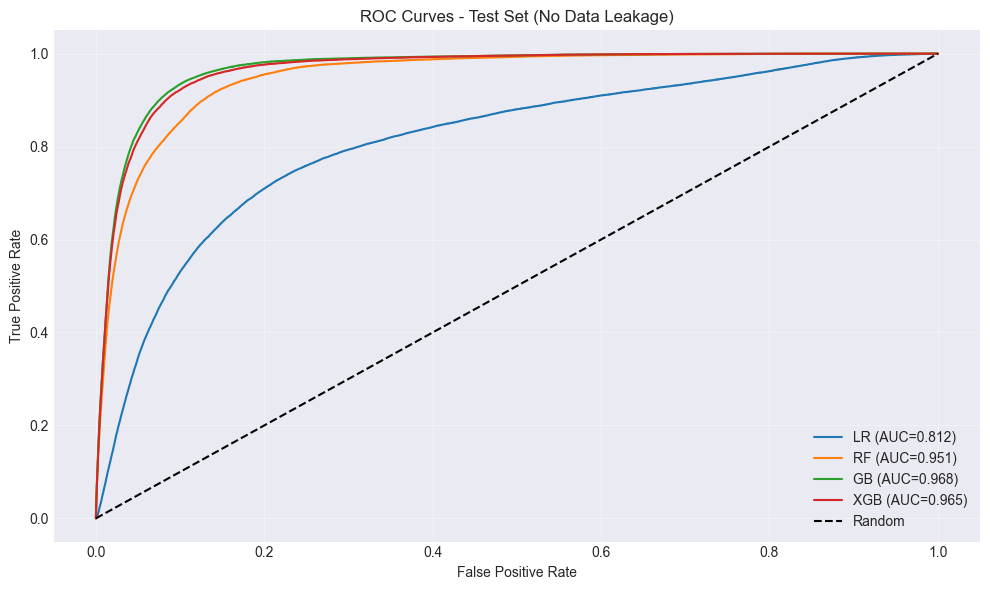

In [40]:
plt.figure(figsize=(10, 6))
models = [("LR", lr_test_prob), ("RF", rf_test_prob), ("GB", gb_test_prob), ("XGB", xgb_test_prob)]
for name, prob in models:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1], [0,1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Test Set (No Data Leakage)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

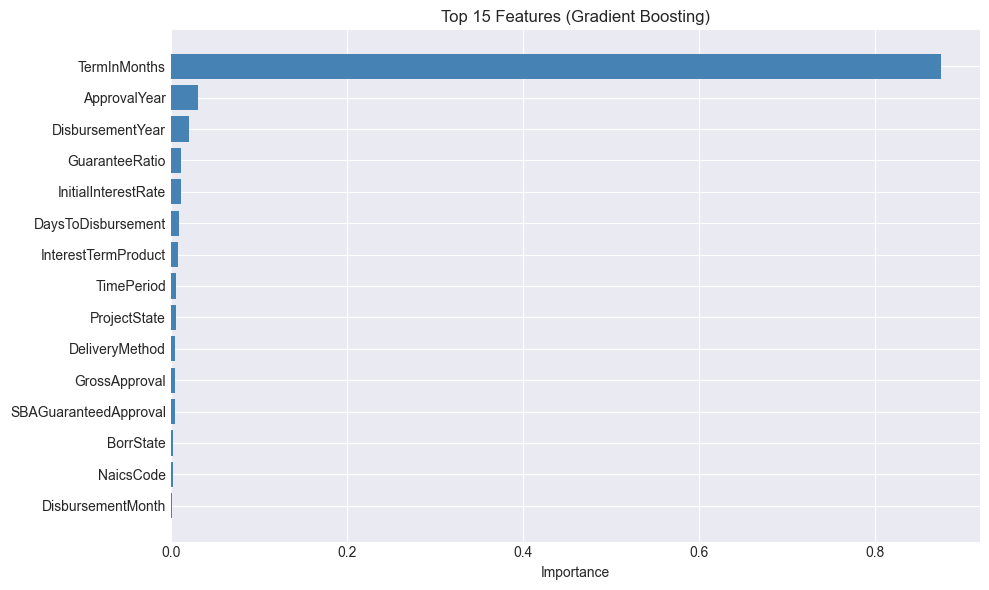

Top 10 Features:
            Feature  Importance
       TermInMonths    0.875708
       ApprovalYear    0.030685
   DisbursementYear    0.020220
     GuaranteeRatio    0.011843
InitialInterestRate    0.011121
 DaysToDisbursement    0.009808
InterestTermProduct    0.008166
         TimePeriod    0.005484
       ProjectState    0.005384
     DeliveryMethod    0.004972


In [41]:
if hasattr(best_model, "feature_importances_"):
    feature_imp = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": best_model.feature_importances_
    }).sort_values("Importance", ascending=False).head(15)
    
    plt.figure(figsize=(10, 6))
    plt.barh(feature_imp["Feature"], feature_imp["Importance"], color="steelblue")
    plt.xlabel("Importance")
    plt.title(f"Top 15 Features ({best_model_name})")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    print("Top 10 Features:")
    print(feature_imp.head(10).to_string(index=False))

## 8. Save Production Model

In [ ]:
import os
os.makedirs("Ml Model", exist_ok=True)

model_artifacts = {
    "model": best_model,
    "model_name": best_model_name,
    "scaler": scaler,
    "imputer_num": imputer_num,
    "imputer_cat": imputer_cat,
    "label_encoders": label_encoders,
    "target_encoder": target_encoder,
    "feature_names": X_train.columns.tolist(),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "high_cardinality": high_cardinality,
    "low_cardinality": low_cardinality,
    "scale_pos_weight": scale_pos_weight,
    "val_auc": best_val_auc,
    "test_auc": best_test_auc
}

with open("Ml Model/credit_risk_model_updated.pkl", "wb") as f:
    pickle.dump(model_artifacts, f)

print(f"✓ Model saved: {best_model_name}")
print(f"  Val AUC: {best_val_auc:.4f}")
print(f"  Test AUC: {best_test_auc:.4f}")
print(f"  Location: Ml Model/credit_risk_model_updated.pkl")

## 9. Pipeline Summary

In [43]:
print("="*70)
print("PRODUCTION-READY CREDIT RISK PREDICTION PIPELINE")
print("="*70)

print(f"DATASET:")
print(f"  Total records: {len(df):,}")
print(f"  Features: {len(X_train.columns)}")
print(f"  Default rate: {y.mean()*100:.2f}%")

print(f"DATA SPLIT:")
print(f"  Train: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Val:   {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test:  {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")

print(f"MODEL PERFORMANCE:")
for _, row in results.sort_values("Test_AUC", ascending=False).iterrows():
    print(f"  {row['Model']}: Val={row['Val_AUC']:.4f}, Test={row['Test_AUC']:.4f}")

print(f"BEST MODEL: {best_model_name}")
print(f"  Validation AUC: {best_val_auc:.4f}")
print(f"  Test AUC: {best_test_auc:.4f}")


print("="*70)

PRODUCTION-READY CREDIT RISK PREDICTION PIPELINE
DATASET:
  Total records: 1,573,141
  Features: 23
  Default rate: 13.33%
DATA SPLIT:
  Train: 943,884 (60.0%)
  Val:   314,628 (20.0%)
  Test:  314,629 (20.0%)
MODEL PERFORMANCE:
  Gradient Boosting: Val=0.9680, Test=0.9678
  XGBoost: Val=0.9653, Test=0.9652
  Random Forest: Val=0.9509, Test=0.9511
  Logistic Regression: Val=0.8121, Test=0.8122
BEST MODEL: Gradient Boosting
  Validation AUC: 0.9680
  Test AUC: 0.9678
